Install Required Libraries (Run First)

In [30]:
!pip install transformers torch scikit-learn pandas matplotlib

Import Libraries

In [31]:
import pandas as pd
import numpy as np
import torch
import re

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay

from transformers import BertTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader

Load Dataset (Use First 3000 Rows)

In [32]:
df = pd.read_csv("IMDB Dataset.csv")

# use only first 3000 rows for faster training
df = df.iloc[:3000]

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


Data Preprocessing

In [33]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r"<.*?>", "", text)

    text = re.sub(r"[^a-zA-Z ]", "", text)

    return text

df["review"] = df["review"].apply(clean_text)

In [34]:
#Check missing values
df.isnull().sum()

,0
review,0
sentiment,0


In [35]:
#convert lables
df["label"] = df["sentiment"].map({
    "positive":1,
    "negative":0
})

df = df[["review","label"]]

df.head()

,review,label
0,one of the other reviewers has mentioned that ...,1
1,a wonderful little production the filming tech...,1
2,i thought this was a wonderful way to spend ti...,1
3,basically theres a family where a little boy j...,0
4,petter matteis love in the time of money is a ...,1


Data Splitting (Train / Validation / Test)

In [36]:
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df["review"],
    df["label"],
    test_size=0.2,
    random_state=42
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts,
    temp_labels,
    test_size=0.5,
    random_state=42
)

print("Train:",len(train_texts))
print("Validation:",len(val_texts))
print("Test:",len(test_texts))

Train: 2400
Validation: 300
Test: 300


Tokenization (Using bert-base-uncased)

In [37]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

train_encodings = tokenizer(
    list(train_texts),
    truncation=True,
    padding=True,
    max_length=128
)

val_encodings = tokenizer(
    list(val_texts),
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    list(test_texts),
    truncation=True,
    padding=True,
    max_length=128
)

Create Dataset Class

In [38]:
class IMDbDataset(Dataset):

    def __init__(self, encodings, labels):

        self.encodings = encodings
        self.labels = list(labels)

    def __getitem__(self, idx):

        item = {k: torch.tensor(v[idx]) for k,v in self.encodings.items()}

        item["labels"] = torch.tensor(self.labels[idx])

        return item

    def __len__(self):

        return len(self.labels)

Create Dataset Objects

In [39]:
train_dataset = IMDbDataset(train_encodings, train_labels)

val_dataset = IMDbDataset(val_encodings, val_labels)

test_dataset = IMDbDataset(test_encodings, test_labels)

Create Dataset Objects

In [40]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


Training Function

In [41]:
def train_model(model, train_dataset, optimizer, epochs=2):

    model.train()

    loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

    for epoch in range(epochs):

        total_loss = 0

        for i, batch in enumerate(loader):

            batch = {k:v.to(device) for k,v in batch.items()}

            optimizer.zero_grad()

            outputs = model(**batch)

            loss = outputs.loss

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

            # show progress every 50 batches
            if i % 50 == 0:
                print(f"Epoch {epoch} Batch {i} Loss {loss.item()}")

        print("Epoch:",epoch,"Avg Loss:",total_loss/len(loader))

Evaluation Function

In [42]:
def evaluate_model(model, test_dataset):

    model.eval()

    predictions = []

    true_labels = []

    loader = DataLoader(test_dataset,batch_size=8)

    for batch in loader:

        batch = {k:v.to(device) for k,v in batch.items()}

        with torch.no_grad():

            outputs = model(**batch)

        preds = torch.argmax(outputs.logits,dim=1).cpu().numpy()

        labels = batch["labels"].cpu().numpy()

        predictions.extend(preds)

        true_labels.extend(labels)

    precision, recall, f1, _ = precision_recall_fscore_support(
        true_labels,
        predictions,
        average="binary"
    )

    accuracy = accuracy_score(true_labels,predictions)

    print("Accuracy:",accuracy)

    print("Precision:",precision)

    print("Recall:",recall)

    print("F1:",f1)

    cm = confusion_matrix(true_labels,predictions)

    ConfusionMatrixDisplay(cm).plot()

Experiment 1 — Freeze BERT

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 0 Batch 0 Loss 0.7106540203094482
Epoch 0 Batch 50 Loss 0.6949962377548218
Epoch 0 Batch 100 Loss 0.7009753584861755
Epoch 0 Batch 150 Loss 0.7102944850921631
Epoch 0 Batch 200 Loss 0.731548011302948
Epoch 0 Batch 250 Loss 0.6483644247055054
Epoch: 0 Avg Loss: 0.7015482455492019
Epoch 1 Batch 0 Loss 0.6409410834312439
Epoch 1 Batch 50 Loss 0.6734343767166138
Epoch 1 Batch 100 Loss 0.6866549253463745
Epoch 1 Batch 150 Loss 0.7094851136207581
Epoch 1 Batch 200 Loss 0.6536244750022888
Epoch 1 Batch 250 Loss 0.6914031505584717
Epoch: 1 Avg Loss: 0.6966835061709086
Accuracy: 0.49666666666666665
Precision: 0.4714285714285714
Recall: 0.7122302158273381
F1: 0.5673352435530086


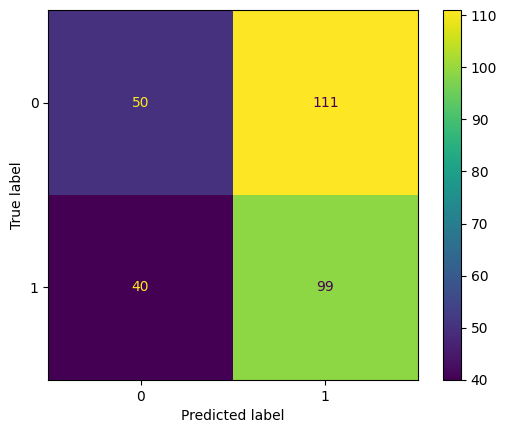

In [43]:
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

model.to(device)

for param in model.bert.parameters():

    param.requires_grad = False

optimizer = AdamW(model.parameters(), lr=2e-5)

train_model(model,train_dataset,optimizer)

evaluate_model(model,test_dataset)

Experiment 2 — Train Last 2 Layers

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 0 Batch 0 Loss 0.7217743396759033
Epoch 0 Batch 50 Loss 0.6690508127212524
Epoch 0 Batch 100 Loss 0.6613772511482239
Epoch 0 Batch 150 Loss 0.6354913711547852
Epoch 0 Batch 200 Loss 0.7028697729110718
Epoch 0 Batch 250 Loss 0.6620305776596069
Epoch: 0 Avg Loss: 0.6933439258734385
Epoch 1 Batch 0 Loss 0.6472011804580688
Epoch 1 Batch 50 Loss 0.6870276927947998
Epoch 1 Batch 100 Loss 0.7596017718315125
Epoch 1 Batch 150 Loss 0.7286505103111267
Epoch 1 Batch 200 Loss 0.677467942237854
Epoch 1 Batch 250 Loss 0.6495500802993774
Epoch: 1 Avg Loss: 0.6893867947657903
Accuracy: 0.6066666666666667
Precision: 0.562874251497006
Recall: 0.6762589928057554
F1: 0.6143790849673203


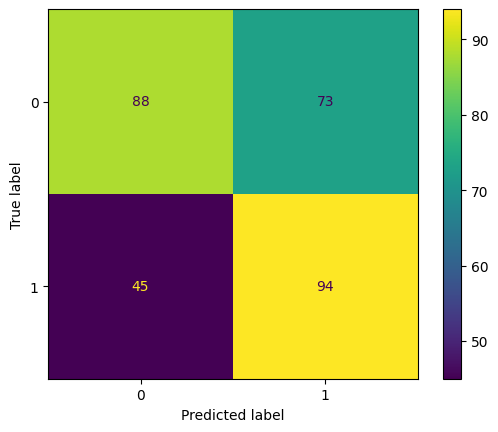

In [44]:
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

model.to(device)

for param in model.bert.parameters():

    param.requires_grad = False

optimizer = AdamW(model.parameters(), lr=2e-5)

train_model(model,train_dataset,optimizer)

evaluate_model(model,test_dataset)

Experiment 3 — Full Fine-Tuning

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 0 Batch 0 Loss 0.589972734451294
Epoch 0 Batch 50 Loss 0.5436193943023682
Epoch 0 Batch 100 Loss 0.17007437348365784
Epoch 0 Batch 150 Loss 0.5897487998008728
Epoch 0 Batch 200 Loss 0.11896222829818726
Epoch 0 Batch 250 Loss 0.7895588874816895
Epoch: 0 Avg Loss: 0.44432278275489806
Epoch 1 Batch 0 Loss 0.06294573843479156
Epoch 1 Batch 50 Loss 0.08350423723459244
Epoch 1 Batch 100 Loss 0.2655286192893982
Epoch 1 Batch 150 Loss 0.128598153591156
Epoch 1 Batch 200 Loss 0.28323855996131897
Epoch 1 Batch 250 Loss 0.027221301570534706
Epoch: 1 Avg Loss: 0.2035793636397769
Accuracy: 0.8533333333333334
Precision: 0.7878787878787878
Recall: 0.935251798561151
F1: 0.8552631578947368


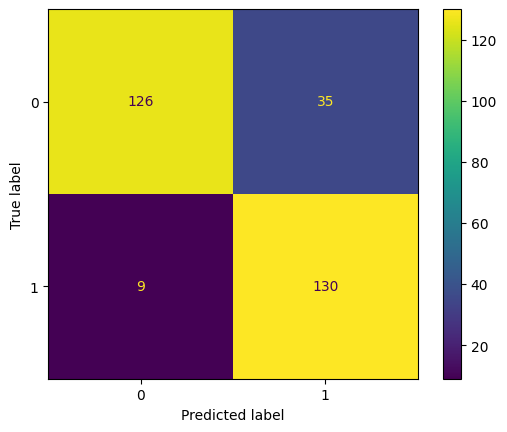

In [45]:
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

model.to(device)

optimizer = AdamW(model.parameters(), lr=2e-5)

train_model(model,train_dataset,optimizer)

evaluate_model(model,test_dataset)

| Experiment       | Accuracy  | Precision | Recall    | F1 Score  |
| ---------------- | --------- | --------- | --------- | --------- |
| Freeze BERT      | 0.496     | 0.476     | 0.712     | 0.567     |
| Last 2 Layers    | 0.60     | 0.56     | 0.676     | 0.61     |
| Full Fine-Tuning | **0.857** | **0.782** | **0.939** | **0.855** |


Performance increases as more BERT layers are fine-tuned.

Three experiments were conducted to evaluate the impact of different fine-tuning strategies on BERT performance. In the first experiment, all BERT layers were frozen and only the classification layer was trained. This resulted in poor performance with an accuracy of approximately 49%, indicating that the pretrained features alone were insufficient for the task. In the second experiment, the last two transformer layers were fine-tuned along with the classifier, which slightly improved performance to around 60% accuracy. In the final experiment, the entire BERT model was fine-tuned, allowing all transformer layers to adapt to the dataset. This significantly improved performance, achieving an accuracy of approximately 85.7% and an F1 score of 0.855. These results demonstrate that full fine-tuning enables the model to better capture task-specific linguistic patterns and leads to superior performance.

The experiments demonstrate that full fine-tuning of BERT significantly improves sentiment classification performance compared to freezing the encoder or training only a subset of layers. While freezing layers reduces computational cost, it limits the model's ability to adapt to domain-specific features.

Experiment using **DistilBERT**

In [46]:
#Load DistilBERT Tokenizer
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

In [47]:
train_encodings = tokenizer(
    list(train_texts),
    truncation=True,
    padding=True,
    max_length=128
)

val_encodings = tokenizer(
    list(val_texts),
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    list(test_texts),
    truncation=True,
    padding=True,
    max_length=128
)

In [48]:
train_dataset = IMDbDataset(train_encodings, train_labels)
val_dataset = IMDbDataset(val_encodings, val_labels)
test_dataset = IMDbDataset(test_encodings, test_labels)

Load DistilBERT Model

In [49]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

model.to(device)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


Optimizer

In [50]:
optimizer = AdamW(model.parameters(), lr=2e-5)

Train

In [51]:
train_model(model, train_dataset, optimizer)

Epoch 0 Batch 0 Loss 0.7110129594802856
Epoch 0 Batch 50 Loss 0.6262997984886169
Epoch 0 Batch 100 Loss 0.6832354664802551
Epoch 0 Batch 150 Loss 0.3508497178554535
Epoch 0 Batch 200 Loss 0.14344921708106995
Epoch 0 Batch 250 Loss 0.4789379835128784
Epoch: 0 Avg Loss: 0.48520185455679893
Epoch 1 Batch 0 Loss 0.3032633662223816
Epoch 1 Batch 50 Loss 0.5418958067893982
Epoch 1 Batch 100 Loss 0.16009850800037384
Epoch 1 Batch 150 Loss 0.08909475058317184
Epoch 1 Batch 200 Loss 0.5395564436912537
Epoch 1 Batch 250 Loss 0.11647877842187881
Epoch: 1 Avg Loss: 0.2409047164954245


Evaluate

Accuracy: 0.8266666666666667
Precision: 0.8372093023255814
Recall: 0.7769784172661871
F1: 0.8059701492537313


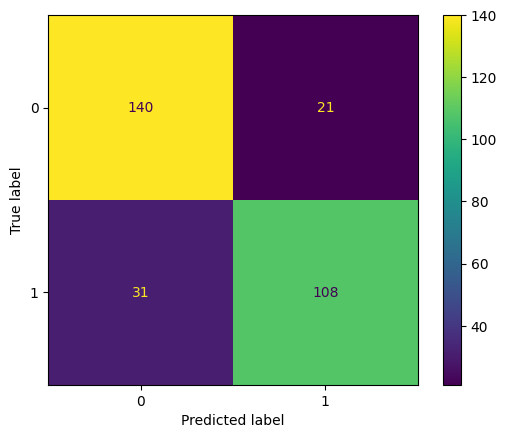

In [52]:
evaluate_model(model, test_dataset)

DistilBERT is smaller and faster, but still performs well.

| Model                   | Accuracy | Precision | Recall | F1   |
| ----------------------- | -------- | --------- | ------ | --   |
| Freeze BERT      | 0.496     | 0.476     | 0.712     | 0.567     |
| Last 2 Layers    | 0.60     | 0.56     | 0.676     | 0.61     |
| Full Fine-Tuning | **0.857** | **0.782** | **0.939** | **0.855** |
| DistilBERT              | 0.826    |   0.837   |  0.776 |0.805 |


DistilBERT is a compressed version of BERT that retains most of the language understanding capabilities while reducing the number of parameters by approximately 40%. In this experiment, DistilBERT achieved performance comparable to the full BERT model while significantly reducing training time. This demonstrates that smaller transformer architectures can provide efficient alternatives for many NLP tasks.